<a href="https://colab.research.google.com/github/Darknigth99/FSI-IA-ENFERMEDADES-PIEL/blob/main/TrabajoFSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este trabajo ha consistido en usar un dataset de fotos de enfermedades de la piel, obtenido del siguiente enlace: https://www.kaggle.com/datasets/pacificrm/skindiseasedataset. El objetivo ha sido entrenar 5 modelos de inteligencias artificiales convolutivas distintas para que clasifiquen las siguientes enfermedades:


1.   Acne
2.   Actinic Keratosis
3.   Benign Tumours
4.   Bullous
5.   Candidiasis
6.   Drug Eruption
7.   Eczema
8.   Infestations Bites
9.   Lichen
10.  Lupus

Adicionalmente, hemos entrenado un moodelo de inteligencia artificial convolutivo usando la técnica de "transfer learning". La IA preentrenada que hemos escogido para esta tarea ha sido Resnet34, debido a que consideramos que sus capas eran adecuadas y el tipo de entrenamiento al que fue sometido era adecuado para el dataset que teníamos.

Los parámetros que hemos ido modificando para plantear las distintas arquitecturas y entrenamientos han sido los siguientes:



*   Orden de los kernels en las capas convolutivas, si están invertidas o no.
*   Dropout y dropout espacial.
*   Número de capas convolutivas y lineales.
*   Número de neuronas en cada capa.
*   Learning rate.
*   Número de épocas.
*   Weight decay.
*   Data augmentation.
*   Batch norm.
*   Average pool y max pool.

Pasamos a explicar en más detalle el código. En primer lugar, vamos a detallar los contenidos de "utilidades".

*   evaluate(model, test_loader)
*   evaluate_with_conf_maxtrix(model, test_loader)
*   plot_conf_matrix()
*   train_with_validation(model, train_loader, dev_loader, criterion, optimizer, epochs)
*   seed_everything(seed)
*   plot_training_history(history)
*   load_model(model, PATH)
*   save_model(model, PATH)

Algunas de estas funciones están sacadas del código proporcionado por el profesorado, tales como evaluate(), train_with_validation(), seed_everything() y
plot_training_history().

En el caso de evaluate_with_conf_matrix(), hemos adaptado el código de clase en la que se explica como mostrar la matriz de confusión y la hemos fusionado con evaluate(), apoyándonos de la función auxiliar plot_conf_matrix().

Por último, creamos dos funciones auxiliares para guardar y cargar modelos, save_model() y load_model() respectivamente.








In [ ]:
import os

from google.colab import drive
drive.mount('/content/drive')

dataset = '/content/drive/MyDrive/DaTaSeT/'

os.listdir(dataset)





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Test', 'Training', 'Models']

In [ ]:
#--------------------------ARQUITECTURA 5-----------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim

# Por si no está definido:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR = 1e-3

class SkinDiseaseModelCNN5(nn.Module):
    def __init__(self, num_classes):
        super(SkinDiseaseModelCNN5, self).__init__()
        self.num_classes = num_classes

        self.conv1 = nn.LazyConv2d(out_channels=256, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        self.conv2 = nn.LazyConv2d(out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.LazyConv2d(out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.LazyConv2d(out_channels=32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)

        self.pool= nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.LazyLinear(128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = self.bn1(self.conv1(x))
        x = self.relu(x)
        x = self.pool(x)

        x = self.bn2(self.conv2(x))
        x = self.relu(x)
        x = self.pool(x)

        x = self.bn3(self.conv3(x))
        x = self.relu(x)
        x = self.pool(x)

        x = self.bn4(self.conv4(x))
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = self.dropout(x)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)
        return x


In [ ]:
#--------------------------ARQUITECTURA 4-----------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim

# Por si no está definido:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR = 1e-3

class SkinDiseaseModelCNN4(nn.Module):
    def __init__(self, num_classes):
        super(SkinDiseaseModelCNN4, self).__init__()
        self.num_classes = num_classes

        self.conv1 = nn.LazyConv2d(out_channels=256, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        self.conv2 = nn.LazyConv2d(out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.LazyConv2d(out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool= nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.LazyLinear(128)
        self.fc2 = nn.LazyLinear(64)
        self.fc3 = nn.LazyLinear(32)
        self.fc4 = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = self.bn1(self.conv1(x))
        x = self.relu(x)
        x = self.pool(x)

        x = self.bn2(self.conv2(x))
        x = self.relu(x)
        x = self.pool(x)

        x = self.bn3(self.conv3(x))
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)
        x = self.dropout(x)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.relu(self.fc3(x))
        x = self.dropout(x)


        x = self.fc4(x)
        return x



In [ ]:
#--------------------------ARQUITECTURA 3-----------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim

# Por si no está definido:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR = 1e-3

class SkinDiseaseModelCNN3(nn.Module):
    def __init__(self, num_classes):
        super(SkinDiseaseModelCNN3, self).__init__()
        self.num_classes = num_classes

        # Capa 1: convolución + activación + pooling
        self.conv1 = nn.Conv2d(3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Capa 2: convolución + activación + pooling
        self.conv2 = nn.Conv2d(32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        #Capa 3:
        self.conv3 = nn.Conv2d(64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        #Capa 4:
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # fully connected
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.bn1(self.conv1(x))
        x = self.relu(x)
        x = self.pool(x)

        x = self.bn2(self.conv2(x))
        x = self.relu(x)
        x = self.pool(x)

        x = self.bn3(self.conv3(x))
        x = self.relu(x)
        x = self.pool(x)

        x = self.bn4(self.conv4(x))
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.fc3(x)
        return x


In [ ]:
#---------------------ARQUITECTURA 2-----------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim

# Por si no está definido:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR = 1e-3

class SkinDiseaseModelCNN2(nn.Module):
    def __init__(self, num_classes):
        super(SkinDiseaseModelCNN2, self).__init__()
        self.num_classes = num_classes

        # Capa 1: convolución + activación + pooling + BatchNorm
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Capa 2: convolución + activación + pooling + BatchNorm
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Capa 3: convolución + activación + pooling + BatchNorm
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Add one more conv layer for better feature extraction
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Maxpool
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Adaptive pooling to handle different spatial dimensions
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # fully connected
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.2)  # Was 0.5
        self.dropout2 = nn.Dropout(0.1)  # Was 0.3
        self.dropout_conv = nn.Dropout2d(0.05)  # Was 0.1

    def forward(self, x):
        # Layer 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.dropout_conv(x)

        # Layer 2
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout_conv(x)

        # Layer 3
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.dropout_conv(x)

        # Layer 4 (new)
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)

        # Adaptive pooling
        x = self.adaptive_pool(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Fully connected layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.relu(self.fc2(x))
        x = self.dropout2(x)

        x = self.fc3(x)
        return x


In [ ]:
#---------------ARQUITECTURA 1---------------------

import torch
import torch.nn as nn
import torch.optim as optim

# Por si no está definido:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR = 1e-3

class SkinDiseaseModelCNN(nn.Module):
    def __init__(self, num_classes):
          super(SkinDiseaseModelCNN, self).__init__()
          self.num_classes = num_classes

          # Capa 1: convolución + BatchNorm + activación + pooling
          self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
          self.bn1 = nn.BatchNorm2d(32)

          # Capa 2: convolución + BatchNorm + activación + pooling
          self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
          self.bn2 = nn.BatchNorm2d(64)

          # Capa 3: convolución + BatchNorm + activación + pooling
          self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
          self.bn3 = nn.BatchNorm2d(128)

          self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Changed to MaxPool
          self.relu = nn.ReLU()
          self.dropout2d = nn.Dropout2d(0.25)  # Spatial dropout

          # Use LazyLinear for convenience (calculates input size automatically)
          self.fc1 = nn.LazyLinear(512)
          self.bn_fc = nn.BatchNorm1d(512)  # BatchNorm for FC layer
          self.dropout = nn.Dropout(0.5)  # Increased from 0.1 to 0.5
          self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Conv block 1
        x = self.relu(self.conv1(x))
        x = self.bn1(x)
        x = self.pool(x)

        # Conv block 2
        x = self.relu(self.conv2(x))
        x = self.bn2(x)
        x = self.pool(x)

        # Conv block 3 with spatial dropout
        x = self.relu(self.conv3(x))
        x = self.bn3(x)
        x = self.pool(x)
        x = self.dropout2d(x)  # Apply spatial dropout

        # Flatten
        x = torch.flatten(x, 1)

        # Fully connected with BatchNorm and dropout
        x = self.fc1(x)
        x = self.bn_fc(x)  # BatchNorm before activation
        x = self.relu(x)
        x = self.dropout(x)  # Increased dropout
        x = self.fc2(x)

        return x



In [ ]:
#---------------------------------UTILIDADES------------------------------
import numpy as np
import torch
import torch.nn.functional as F

from sklearn.metrics import confusion_matrix
import seaborn as sns


def evaluate(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()  # Poner el modelo en modo evaluación
    correct = 0
    total = test_loader.dataset.__len__() # Total de muestras en el conjunto de test

    with torch.no_grad():  # No calcular gradientes
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Mover datos al dispositivo
            outputs = model(inputs)  # Forward pass
            _, predicted = torch.max(outputs, 1)  # Obtener las predicciones
            correct += (predicted == labels).sum().item()  # Actualizar el contador de aciertos
    accuracy = 100 * correct / total if total > 0 else 0.0
    return accuracy


def evaluate_with_conf_matrix(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()  # Poner el modelo en modo evaluación
    correct = 0
    total = test_loader.dataset.__len__() # Total de muestras en el conjunto de test

    all_preds = []
    all_labels = []

    with torch.no_grad():  # No calcular gradientes
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Mover datos al dispositivo
            outputs = model(inputs)  # Forward pass
            _, predicted = torch.max(outputs, 1)  # Obtener las predicciones
            correct += (predicted == labels).sum().item()  # Actualizar el contador de aciertos

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    plot_conf_matrix(all_labels, all_preds)
    accuracy = 100 * correct / total if total > 0 else 0.0
    return accuracy

def plot_conf_matrix(all_labels, all_preds):
      classes = (
          'Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous',
          'Candidiasis', 'Drug_Eruption', 'Eczema', 'Infestations_Bites',
          'Lichen', 'Lupus')

      cm = confusion_matrix(all_labels, all_preds)
      plt.figure(figsize=(10, 8))
      sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
      plt.xlabel('Predicted')
      plt.ylabel('True')
      plt.title('Confusion Matrix')
      plt.show()

def train_with_validation(model, train_loader, dev_loader, criterion, optimizer, epochs=20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'dev_loss': [],
        'dev_acc': [],
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:

            optimizer.zero_grad()  # Limpiar gradientes
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)  # Forward
            #n_classes = outputs.shape[1]
            #labels_one_hot = F.one_hot(labels, num_classes=n_classes).float()

            loss = criterion(outputs, labels)  # Pérdida
            loss.backward()  # Backward
            optimizer.step()  # Update

            running_loss += loss.item()

            # Accuracy en train
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        avg_train_loss = running_loss / max(1, len(train_loader))
        train_acc = 100.0 * correct / max(1, total)

        # ---- Validación (loss) ----
        model.eval()
        dev_running_loss = 0.0
        with torch.no_grad():
            for inputs, labels in dev_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                #n_classes = outputs.shape[1]
                #labels_one_hot = F.one_hot(labels, num_classes=n_classes).float()
                dev_loss = criterion(outputs, labels)
                dev_running_loss += dev_loss.item()
        avg_dev_loss = dev_running_loss / max(1, len(dev_loader))

        # ---- Validación (accuracy) usando tu función evaluate ----
        dev_acc = evaluate(model, dev_loader)  # imprime y devuelve accuracy

        # Guardar histórico
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['dev_loss'].append(avg_dev_loss)
        history['dev_acc'].append(dev_acc)

        # Log por época (conciso y claro)
        print(f'[Epoch {epoch + 1}] '
              f'train_loss: {avg_train_loss:.3f} | train_acc: {train_acc:.2f}% | '
              f'dev_loss: {avg_dev_loss:.3f} | dev_acc: {dev_acc:.2f}%')

    return model, history


def seed_everything(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def plot_training_history(history):
    """
    Dibuja las curvas de loss y accuracy (train y dev) guardadas en el diccionario 'history'.
    Espera claves: 'train_loss', 'train_acc', 'dev_loss', 'dev_acc'.
    """
    epochs = range(1, len(history['train_loss']) + 1)

    # --- Loss ---
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['dev_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    # --- Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['dev_acc'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def load_model(model, path):
    model.load_state_dict(torch.load(path, weights_only=True))
    return model

def save_model(model, path):
    torch.save(model.state_dict(), path)






A la hora de cargar en dataset, hemos utilizado un batch de tamaño 16 ó 32 para no volcar todas las imágenes en la RAM de la GPU. Por otro lado, tenemos diferentes niveles de data augmentation definidos para lograr un mejor entrenamiento y aprendizaje.

In [ ]:
#---------------------------CARGA DEL DATASET--------------------------

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.nn import Conv2d, Linear, BatchNorm2d, ReLU, MaxPool2d
from torchvision import datasets
import torch.nn as nn
import torch.optim as optim

training_data_dir = "/content/drive/MyDrive/DaTaSeT/Training"
validation_data_dir = "/content/drive/MyDrive/DaTaSeT/Test"



BATCH_SIZE = 32

no_augmentation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


strong_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats
])

mild_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Mild color changes
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

balanced_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(training_data_dir, transform=no_augmentation)
validation_dataset = datasets.ImageFolder(validation_data_dir, transform=val_transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = torch.utils.data.DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

dataiter = iter(validation_loader)
images, labels = next(dataiter)

print("\n--- Información del dataset ---")
print(f"Número de imágenes de entrenamiento: {len(train_dataset)}")
print(f"Número de imágenes de prueba: {len(validation_dataset)}")
print(f"Tamaño de una imagen: {train_dataset[0][0].shape}")

print("\n--- Información del batch ---")
print(f"Shape de images: {images.shape}")
print(f"Shape de labels: {labels.shape}")
print(f"Etiquetas del batch: {labels}")


--- Información del dataset ---
Número de imágenes de entrenamiento: 6131
Número de imágenes de prueba: 679
Tamaño de una imagen: torch.Size([3, 224, 224])

--- Información del batch ---
Shape de images: torch.Size([32, 3, 224, 224])
Shape de labels: torch.Size([32])
Etiquetas del batch: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])


In [ ]:
#--------------------------ENTRENAMIENTO DEL MODELO----------------------------------
from torch.optim.lr_scheduler import ReduceLROnPlateau

PATH = "/content/drive/MyDrive/DaTaSeT/Models/Modeloarq1.pth"
PATH2 = "/content/drive/MyDrive/DaTaSeT/Models/Modeloarq2.pth"
PATH3 = "/content/drive/MyDrive/DaTaSeT/Models/Modeloarq3.pth"
PATH4 = "/content/drive/MyDrive/DaTaSeT/Models/Modeloarq4.pth"
PATH5 = "/content/drive/MyDrive/DaTaSeT/Models/Modeloarq5.pth"

LR = 1e-3
seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cnn = SkinDiseaseModelCNN(10).to(DEVICE)
#model_cnn = SkinDiseaseModelCNN2(10)
#model_cnn = SkinDiseaseModelCNN3(10)

model_cnn.load_state_dict(torch.load("/content/drive/MyDrive/DaTaSeT/Models/Modeloarq1_v2.pth", map_location=DEVICE))


criterion = nn.CrossEntropyLoss()
#optimizer = optim.AdamW(model_cnn.parameters(), lr=LR, weight_decay=1e-4)
optimizer = optim.AdamW(model_cnn.parameters(), lr=1e-4, weight_decay=1e-4)
#optimizer = optim.AdamW(model_cnn.parameters(), lr=5e-4, weight_decay=1e-4)

#optimizer = optim.AdamW(model_cnn.parameters(), lr=LR, weight_decay=1e-2)
#optimizer = optim.AdamW(model_cnn.parameters(), lr=2e-3, weight_decay=1e-2)

#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5)

dev_loader = validation_loader

model, history = train_with_validation(
    model = model_cnn,
    train_loader=train_loader,
    dev_loader = validation_loader,
    criterion = criterion,
    optimizer = optimizer,
    epochs = 15
)

acc = evaluate_with_conf_matrix(model, validation_loader)
print(acc)
print(history)

plot_training_history(history)

torch.save(model_cnn.state_dict(), "/content/drive/MyDrive/DaTaSeT/Models/Modeloarq1_v3.pth")

=== STAGE 2: Fine-tuning with stronger augmentation ===
[Epoch 1] train_loss: 1.562 | train_acc: 47.45% | dev_loss: 1.528 | dev_acc: 50.22%
[Epoch 2] train_loss: 1.473 | train_acc: 50.15% | dev_loss: 1.518 | dev_acc: 50.52%
[Epoch 3] train_loss: 1.440 | train_acc: 51.02% | dev_loss: 1.464 | dev_acc: 50.81%
[Epoch 4] train_loss: 1.384 | train_acc: 52.08% | dev_loss: 1.468 | dev_acc: 50.96%
[Epoch 5] train_loss: 1.343 | train_acc: 54.71% | dev_loss: 1.437 | dev_acc: 50.81%
[Epoch 6] train_loss: 1.291 | train_acc: 56.17% | dev_loss: 1.472 | dev_acc: 51.10%
[Epoch 7] train_loss: 1.270 | train_acc: 57.69% | dev_loss: 1.448 | dev_acc: 52.72%
[Epoch 8] train_loss: 1.216 | train_acc: 58.42% | dev_loss: 1.464 | dev_acc: 53.02%
[Epoch 9] train_loss: 1.153 | train_acc: 60.90% | dev_loss: 1.426 | dev_acc: 52.72%
[Epoch 10] train_loss: 1.106 | train_acc: 62.22% | dev_loss: 1.424 | dev_acc: 54.34%
54.34462444771723
{'train_loss': [1.5623637147558231, 1.4731515782574813, 1.4403265348325174, 1.3840595

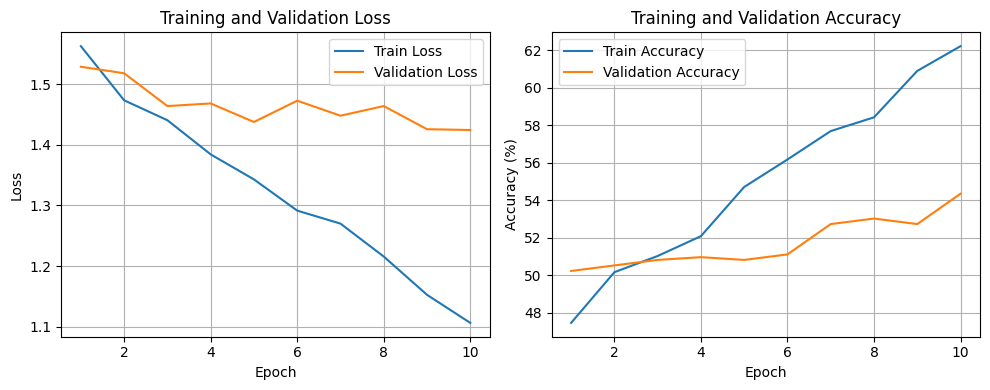

In [ ]:
import torch
from torchvision import transforms, datasets
import torch.nn as nn

# ===== STAGE 2: Continue training with stronger augmentation =====
PATH3 = "/content/drive/MyDrive/DaTaSeT/Models/Modeloarq3.pth"

BATCH_SIZE = 16
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

training_data_dir = "/content/drive/MyDrive/DaTaSeT/Training"
validation_data_dir = "/content/drive/MyDrive/DaTaSeT/Test"


# Define Stage 2 transforms (with augmentation)
stage2_transform = transforms.Compose([
    transforms.Resize((240, 240)),  # Resize slightly larger
    transforms.RandomCrop(224),     # Then random crop to 224x224
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mild_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Mild color changes
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

moderate_transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Slightly larger
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),  # Add vertical flip
    transforms.RandomRotation(10),  # Small rotation
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

strong_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# Load dataset AGAIN with Stage 2 transforms
train_dataset_stage2 = datasets.ImageFolder(
    training_data_dir,
    transform=mild_transform # Now using stronger augmentation
)

train_loader_stage2 = torch.utils.data.DataLoader(
    train_dataset_stage2,
    batch_size=BATCH_SIZE,
    shuffle=True
)


model_cnn_stage2 = SkinDiseaseModelCNN3(10)
model_cnn_stage2.load_state_dict(torch.load("/content/drive/MyDrive/DaTaSeT/Models/Modeloarq3_re2.pth", map_location=DEVICE))

# Use smaller learning rate for fine-tuning
optimizer_stage2 = optim.Adam(model_cnn_stage2.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
dev_loader = validation_loader

print("=== STAGE 2: Fine-tuning with stronger augmentation ===")
model_final, history_final = train_with_validation(
    model=model_cnn_stage2,
    train_loader=train_loader_stage2,  # Using NEW data loader with augmentation
    dev_loader=validation_loader,      # Same validation loader
    criterion=criterion,
    optimizer=optimizer_stage2,
    epochs=10  # Train for more epochs
)

acc = evaluate(model_final, validation_loader)
print(acc)
print(history_final)

plot_training_history(history_final)

torch.save(model_cnn_stage2.state_dict(), "/content/drive/MyDrive/DaTaSeT/Models/Modeloarq3_v4.pth")



Los resultados de los entrenamientos de estos modelos de inteligencia artificial los detallaremos uno por uno y en orden. Adicionalmente, cabe recalcar que nos hemos quedado con los modelos que han dado los mejores resultados.



1.   
    * Accuracy training y accuracy test:\
2.   
    * Accuracy training y accuracy test:\
    [Epoch 35] train_loss: 1.355 | train_acc: 53.40% | dev_loss: 1.502 | dev_acc: 49.04% \
    [Epoch 36] train_loss: 1.321 | train_acc: 53.82% | dev_loss: 1.476 | dev_acc: 49.78%\
    [Epoch 37] train_loss: 1.326 | train_acc: 54.12% | dev_loss: 1.508 | dev_acc: 49.34%\
    [Epoch 38] train_loss: 1.315 | train_acc: 54.00% | dev_loss: 1.469 | dev_acc: 50.96%\
    [Epoch 39] train_loss: 1.297 | train_acc: 54.53% | dev_loss: 1.524 | dev_acc: 48.75%\
    [Epoch 40] train_loss: 1.291 | train_acc: 55.26% | dev_loss: 1.522 | dev_acc: 50.66%
    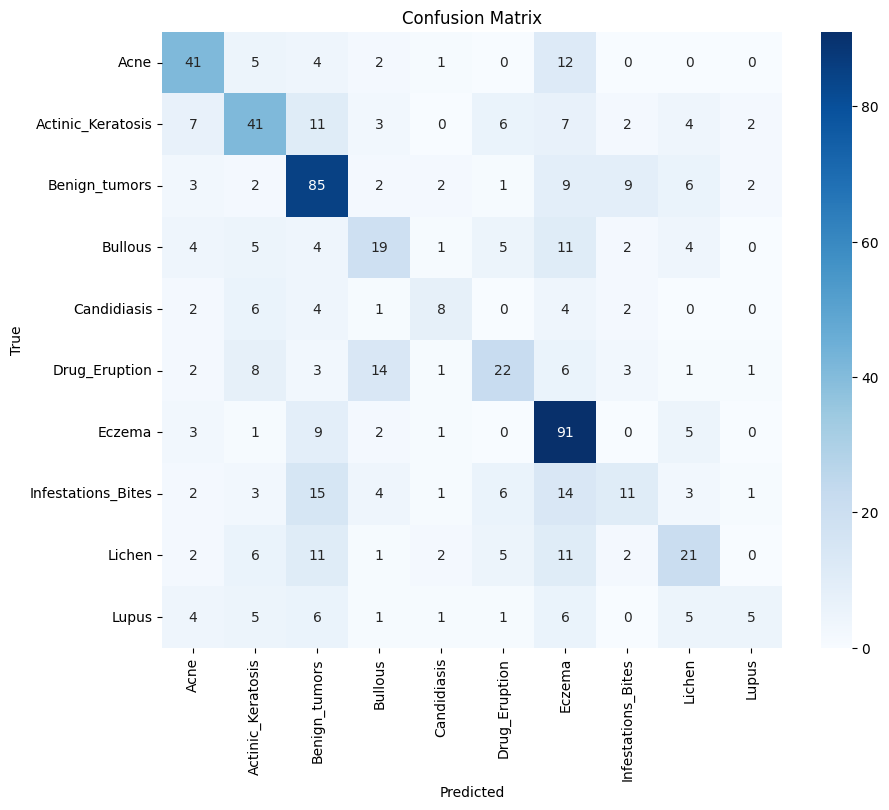
    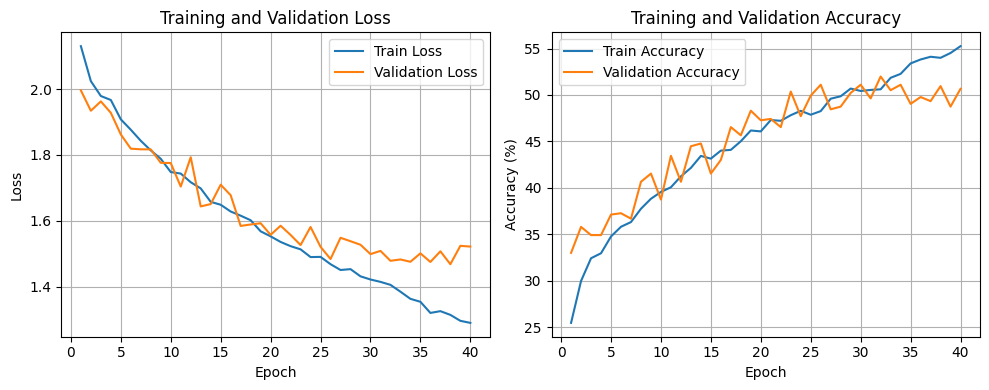
3.
    * Accuracy training y accuracy test:\
    [Epoch 1] train_loss: 1.562 | train_acc: 47.45% | dev_loss: 1.528 | dev_acc: 50.22%\
    [Epoch 2] train_loss: 1.473 | train_acc: 50.15% | dev_loss: 1.518 | dev_acc: 50.52%\
    [Epoch 3] train_loss: 1.440 | train_acc: 51.02% | dev_loss: 1.464 | dev_acc: 50.81%\
    [Epoch 4] train_loss: 1.384 | train_acc: 52.08% | dev_loss: 1.468 | dev_acc: 50.96%\
    [Epoch 5] train_loss: 1.343 | train_acc: 54.71% | dev_loss: 1.437 | dev_acc: 50.81%\
    [Epoch 6] train_loss: 1.291 | train_acc: 56.17% | dev_loss: 1.472 | dev_acc: 51.10%\
    [Epoch 7] train_loss: 1.270 | train_acc: 57.69% | dev_loss: 1.448 | dev_acc: 52.72%\
    [Epoch 8] train_loss: 1.216 | train_acc: 58.42% | dev_loss: 1.464 | dev_acc: 53.02%\
    [Epoch 9] train_loss: 1.153 | train_acc: 60.90% | dev_loss: 1.426 | dev_acc: 52.72%\
    [Epoch 10] train_loss: 1.106 | train_acc: 62.22% | dev_loss: 1.424 | dev_acc: 54.34%\
4.
    * Accuracy training y accuracy test:
    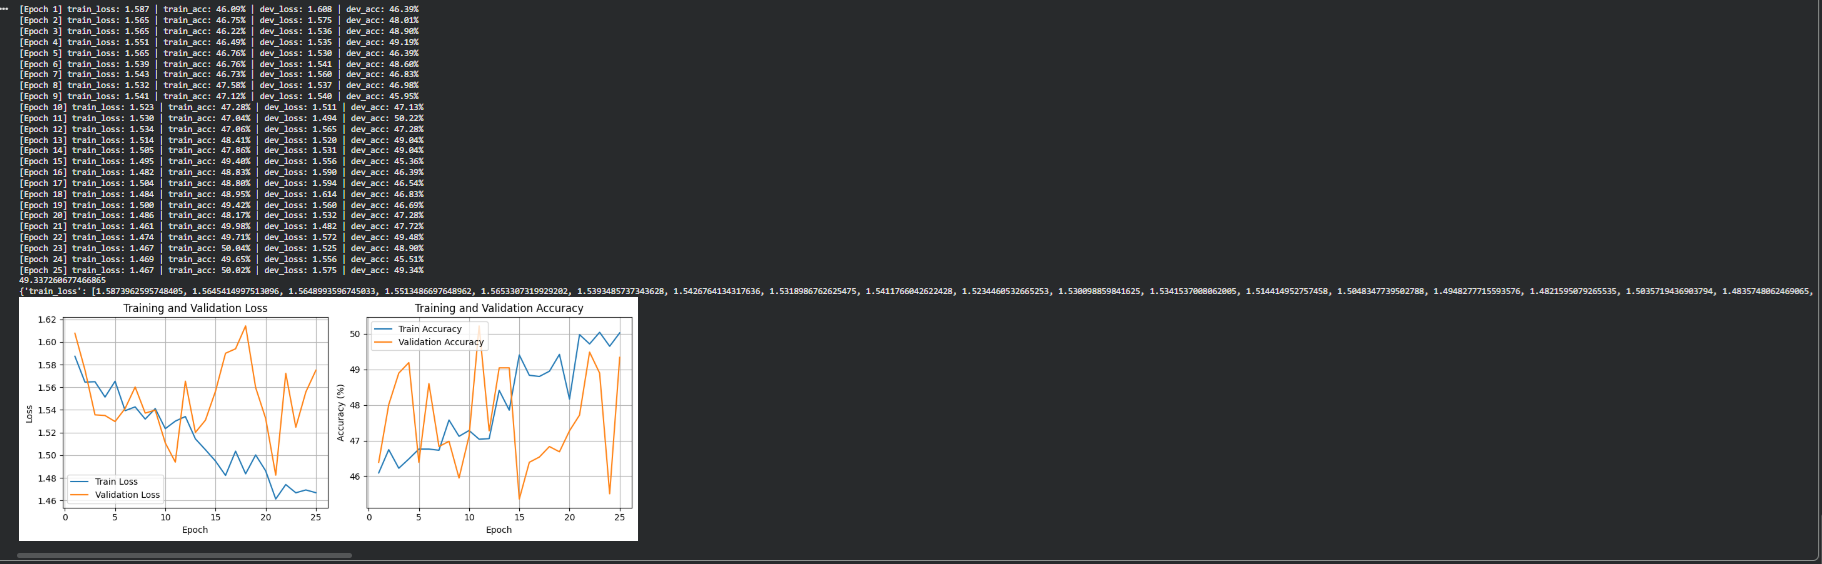
5.
    * Accuracy training y accuracy test:
6.
    * Accuracy training y accuracy test:

